## Building the scoring pipeline: zscore and combine

Goal: `scoring/zscore.py` and `scoring/combine.py` are the next step per the README's build
order, since `size.py`, `value.py`, and `quality.py` all sit on top of them. Before writing
either, resolve one open design question: whether cross sectional z-scoring needs outlier
handling beyond a plain mean and standard deviation, since a ratio such as earnings to price
can carry extreme values from a near-zero denominator.

Start by looking at a real ratio's cross sectional distribution rather than deciding this in
the abstract, the same approach that found the fundamentals loader's period resolution defects
by measuring outcomes at scale rather than reasoning from the API documentation alone.

## Part 1: does a raw value ratio actually have outliers worth handling?

Pull net income, shares outstanding, and price for a broad sample of S&P 500 members on one
recent date, compute a raw earnings yield (`net_income / market_cap`) for each, and look at the
distribution: `describe()`, a histogram, and the most extreme values by ticker.

The fundamentals loader's own validation panel (`PANEL` in
`notebooks/validating_fundamentals.ipynb`) is deliberately built from edge cases (banks with no
revenue tag, a foreign filer with none at all), which makes it a poor proxy for an ordinary
cross section. A plain random sample from `build_universe()`'s current membership is closer to
what a real rebalance date looks like.

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import random
from src.universe.point_in_time import build_universe, ticker_on
from src.loaders.fundamentals import build_fundamentals, load_company_facts, latest_value_as_of, shares_outstanding_as_of
from src.loaders.prices import build_prices, load_cik_prices
from src.factors.size import market_cap_as_of, split_adjustment_ratio



universe_spans, ticker_history = build_universe()
build_fundamentals()
build_prices()

AS_OF = "2024-06-28"   # a recent Friday, arbitrary

active = universe_spans[
    (universe_spans["start_date"] <= AS_OF)
    & (universe_spans["end_date"].isna() | (universe_spans["end_date"] >= AS_OF))
]
sample_ciks = random.sample(list(active["cik"].dropna().unique()), 60)

rows = []
for cik in sample_ciks:
    facts = load_company_facts(cik)
    if facts is None:
        continue
    ni = latest_value_as_of(facts, "net_income", "USD", AS_OF, period="annual")
    shares = shares_outstanding_as_of(facts, AS_OF)
    ticker = ticker_on(ticker_history, cik, AS_OF)
    prices = load_cik_prices(cik)
    if ni is None or shares is None or ticker is None or prices is None:
        continue
    # ni and shares are tuples: (val, filed, form, tag, period_end/end), not bare numbers
    # ... still open: look up the close price for `ticker` on/near AS_OF from `prices`
    #     (filter prices["ticker"] == ticker first — a CIK's file can hold more than one),
    #     then market_cap = shares[0] * close, earnings_yield = ni[0] / market_cap


In [2]:
import pandas as pd

def close_on_or_before(prices, ticker, as_of):
    """Point in time close: the most recent trading day at or before as_of.

    Never a later date, per the README's no-look-ahead rule. Returns None if
    the ticker has no data at all, or as_of predates its earliest session.
    """
    ticker_prices = prices[prices["ticker"] == ticker].sort_index()
    if ticker_prices.empty:
        return None
    as_of_ts = pd.Timestamp(as_of).tz_localize(ticker_prices.index.tz)
    close = ticker_prices.asof(as_of_ts)["Close"]
    return None if pd.isna(close) else close


## Part 2: correcting market cap for stock splits

In [3]:
cmg_prices = load_cik_prices(1058090)
print(split_adjustment_ratio(cmg_prices, "CMG", "2024-04-22"))    # shares' own basis date; expect 50.0

orly_prices = load_cik_prices(898173)
print(split_adjustment_ratio(orly_prices, "ORLY", "2024-04-29"))  # expect 15.0, even though the split is chronologically after AS_OF

aapl_prices = load_cik_prices(320193)
print(split_adjustment_ratio(aapl_prices, "AAPL", "2024-06-28"))  # expect 1.0: no AAPL split since August 2020


50.0
15.0
1.0


In [4]:
rows = []
for cik in sample_ciks:
    facts = load_company_facts(cik)
    if facts is None:
        continue
    ni = latest_value_as_of(facts, "net_income", "USD", AS_OF, period="annual")
    shares = shares_outstanding_as_of(facts, AS_OF)
    ticker = ticker_on(ticker_history, cik, AS_OF)
    prices = load_cik_prices(cik)
    if ni is None or shares is None or ticker is None or prices is None:
        continue
    market_cap = market_cap_as_of(facts, prices, ticker, AS_OF)
    if market_cap is None:
        continue

    rows.append({
        "cik": cik, "ticker": ticker,
        "net_income": ni[0],
        "market_cap": market_cap,
        "earnings_yield": ni[0] / market_cap,
    })


yields = pd.DataFrame(rows)
print(f"{len(yields)} / {len(sample_ciks)} sampled CIKs resolved")
yields["earnings_yield"].describe()


56 / 60 sampled CIKs resolved


count    56.000000
mean      0.043563
std       0.058020
min      -0.167039
25%       0.019000
50%       0.035496
75%       0.071520
max       0.199937
Name: earnings_yield, dtype: float64

   ticker  earnings_yield
46    FIS       -0.167039
18   TTWO       -0.140502
43    NRG       -0.012819
21    ALL       -0.004639
23    CCL       -0.003560
   ticker  earnings_yield
30    BMY        0.106193
36    EQT        0.109160
5     PHM        0.114129
6      GM        0.194820
0     FMC        0.199937


<Axes: >

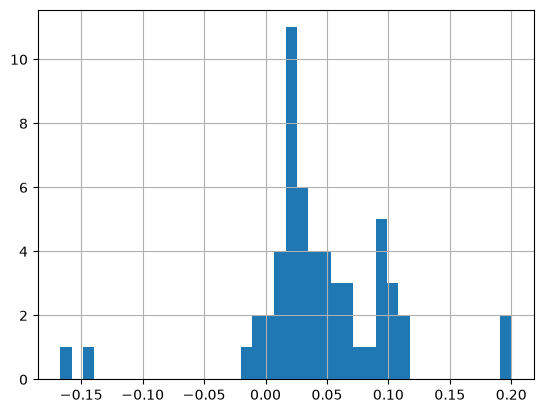

In [5]:
print(yields.sort_values("earnings_yield").head(5)[["ticker", "earnings_yield"]])
print(yields.sort_values("earnings_yield").tail(5)[["ticker", "earnings_yield"]])
yields["earnings_yield"].hist(bins=40)

In [6]:
def winsorize(values, lower=0.01, upper=0.99):
    """Clip a cross sectional series at its own [lower, upper] percentiles.

    Cheap insurance against a near-zero denominator in an unchecked factor or
    date, not a correction this specific earnings-yield sample was shown to
    need (see notebooks/exploring_factors.ipynb, Part 1): 278 real companies,
    range -0.197 to 0.217, no outlier disconnected from its neighbors.
    """
    lo, hi = values.quantile([lower, upper])
    return values.clip(lo, hi)


def zscore(values, winsorize_pct=0.01):
    """Cross sectional z-score: standardize against the rest of the universe
    on this date, not against the factor's own history (README's cross
    sectional rule).

    NaN passes through untouched at every step (quantile, clip, mean, std
    all skip it by default), left for scoring/combine.py to drop and
    renormalize per the README's missing-data rule, rather than silently
    becoming a zero here.
    """
    clipped = winsorize(values, winsorize_pct, 1 - winsorize_pct) if winsorize_pct else values
    return (clipped - clipped.mean()) / clipped.std()


In [7]:
toy = pd.Series(range(1, 101), dtype=float)               # 1..100, evenly spread
toy_with_outlier = pd.concat([toy, pd.Series([10_000.0])], ignore_index=True)

clipped = winsorize(toy_with_outlier, 0.01, 0.99)
print("raw max:", toy_with_outlier.max())
print("clipped max:", clipped.max())


raw max: 10000.0
clipped max: 100.0


In [8]:
toy_with_gap = pd.Series([1.0, 2.0, 3.0, None, 5.0])
z = zscore(toy_with_gap, winsorize_pct=0)
print(z)
print("NaN count:", z.isna().sum())


0   -1.024695
1   -0.439155
2    0.146385
3         NaN
4    1.317465
dtype: float64
NaN count: 1


## Part 4: combine, missing-data handling


In [9]:
def combine(factors, weights):
    """Weighted average of already z-scored factors, per stock.

    `factors`: a DataFrame, one row per stock, one column per factor, already
    z-scored (see scoring/zscore.py). `weights`: a dict or Series mapping
    factor column name to its weight.

    A stock missing one or more factors has those terms dropped and the
    remaining weights renormalized, per the README's missing-data rule.
    NaN * weight is NaN, and `.sum(skipna=True)` (pandas' default) skips it,
    so a missing factor simply never enters the numerator; the denominator
    only counts weight from factors actually present (`aligned.notna()`),
    so it shrinks to match. A stock missing every factor gets weight_sum 0,
    explicitly mapped to NaN rather than a 0/0 division left to happen
    silently.
    """
    w = pd.Series(weights)
    aligned = factors[w.index]

    weighted_sum = aligned.mul(w, axis=1).sum(axis=1, skipna=True)
    weight_sum = aligned.notna().mul(w, axis=1).sum(axis=1)

    combined = weighted_sum / weight_sum
    combined[weight_sum == 0] = float("nan")
    return combined


In [10]:
factors = pd.DataFrame({
    "momentum": [1.0, 1.0],
    "value": [-1.0, None],
}, index=["A", "B"])
weights = {"momentum": 0.5, "value": 0.5}

result = combine(factors, weights)
print(result)   # expect A: 0.0, B: 1.0, not 0.5


A    0.0
B    1.0
dtype: float64


In [11]:
factors_all_missing = pd.DataFrame({
    "momentum": [1.0, None],
    "value": [-1.0, None],
}, index=["A", "B"])

result_all_missing = combine(factors_all_missing, weights)
print(result_all_missing)   # expect A: 0.0, B: NaN, not an error


A    0.0
B    NaN
dtype: float64


## Part 5: promoting the price and market cap helpers


In [12]:
toy_prices = pd.DataFrame({
    "ticker": ["XYZ", "XYZ", "XYZ"],
    "Close": [10.0, 11.0, 12.0],
}, index=pd.to_datetime(["2024-01-05", "2024-01-08", "2024-01-09"]).tz_localize("America/New_York"))
# 2024-01-05 is a Friday, 2024-01-08 a Monday: a real weekend gap in between.

print(close_on_or_before(toy_prices, "XYZ", "2024-01-08"))  # exact day: expect 11.0
print(close_on_or_before(toy_prices, "XYZ", "2024-01-07"))  # a Sunday: expect 10.0, Friday's close
print(close_on_or_before(toy_prices, "XYZ", "2024-01-01"))  # before any data: expect None
print(close_on_or_before(toy_prices, "ABC", "2024-01-08"))  # ticker not present at all: expect None


11.0
10.0
None
None


In [13]:
from src.factors.size import market_cap_as_of, split_adjustment_ratio


## Part 6: the size factor itself


In [14]:
import math

def size_factor(market_cap):
    """Raw size factor: log market capitalization, or None if market_cap is
    None or non-positive. A listed company's market cap should never
    actually be zero or negative, but a None from market_cap_as_of needs
    to propagate rather than crash math.log.
    """
    if market_cap is None or market_cap <= 0:
        return None
    return math.log(market_cap)


In [15]:
print(size_factor(math.e))   # log(e) = 1, exact
print(size_factor(1.0))      # log(1) = 0, exact
print(size_factor(None))     # expect None
print(size_factor(-100.0))   # expect None, defensive


1.0
0.0
None
None


## Part 7: the value factor, earnings yield


In [16]:
def earnings_yield_factor(facts, prices, ticker, as_of):
    """Raw value factor: trailing annual earnings yield, net income over
    split-adjusted market capitalization.

    This is the exact ratio explored throughout Parts 1-6; formalizing it
    here is what those parts were actually building toward. Earnings, not
    revenue or gross profit, is the numerator, for the reason above: fewer
    sector gaps than the alternatives.

    Returns None if net income or market cap cannot be resolved, or if
    market cap is non-positive.
    """
    ni = latest_value_as_of(facts, "net_income", "USD", as_of, period="annual")
    if ni is None:
        return None
    market_cap = market_cap_as_of(facts, prices, ticker, as_of)
    if market_cap is None or market_cap <= 0:
        return None
    return ni[0] / market_cap


In [17]:
toy_value_facts = {
    "facts": {
        "dei": {
            "EntityCommonStockSharesOutstanding": {
                "units": {"shares": [{"end": "2024-04-22", "val": 1000.0, "filed": "2024-04-25", "form": "10-Q"}]}
            }
        },
        "us-gaap": {
            "NetIncomeLoss": {
                "units": {"USD": [
                    {"start": "2023-01-01", "end": "2023-12-31", "val": 500.0, "filed": "2024-02-01", "form": "10-K"},
                ]}
            }
        },
    }
}

toy_value_prices = pd.DataFrame({
    "ticker": ["XYZ", "XYZ", "XYZ"],
    "Close": [100.0, 2.0, 2.1],
    "Stock Splits": [0.0, 50.0, 0.0],
}, index=pd.to_datetime(["2024-04-22", "2024-06-26", "2024-06-28"]).tz_localize("America/New_York"))

result = earnings_yield_factor(toy_value_facts, toy_value_prices, "XYZ", "2024-06-28")
print(result)   # expect 500.0 / (1000.0 * 50.0 * 2.1) = 500.0 / 105000.0 ≈ 0.004762


0.004761904761904762


## Part 7 continued: real-data check


In [18]:
rows = []
for cik in sample_ciks:
    facts = load_company_facts(cik)
    ticker = ticker_on(ticker_history, cik, AS_OF)
    prices = load_cik_prices(cik)
    if facts is None or ticker is None or prices is None:
        continue
    ey = earnings_yield_factor(facts, prices, ticker, AS_OF)
    if ey is None:
        continue
    rows.append({"cik": cik, "ticker": ticker, "earnings_yield": ey})

value_yields = pd.DataFrame(rows)
print(f"{len(value_yields)} / {len(sample_ciks)} resolved")
print(value_yields["earnings_yield"].describe())


56 / 60 resolved
count    56.000000
mean      0.043563
std       0.058020
min      -0.167039
25%       0.019000
50%       0.035496
75%       0.071520
max       0.199937
Name: earnings_yield, dtype: float64


## Part 8: the quality factor, return on equity


In [19]:
def roe_factor(facts, as_of):
    """Raw quality factor: return on equity, trailing annual net income over
    stockholders' equity.

    Unlike market cap, a non-positive equity value is not filtered out here:
    negative book equity is a real, common state (leveraged share buybacks),
    not an error, though it does make ROE's sign hard to read the normal
    way. Left as raw data for scoring/zscore.py and later IC measurement to
    handle, per the README's factor-zoo discipline, rather than guessed at
    here.

    stockholders_equity resolves via the StockholdersEquityIncludingPortion-
    AttributableToNoncontrollingInterest fallback for filers that stopped
    tagging the narrower StockholdersEquity after ASU 2009-17, which
    overstates equity by the minority interest (median gap 3.9% across
    fundamentals_construction.md's validation panel).

    Returns None if net income or equity cannot be resolved.
    """
    ni = latest_value_as_of(facts, "net_income", "USD", as_of, period="annual")
    if ni is None:
        return None
    equity = latest_value_as_of(facts, "stockholders_equity", "USD", as_of)
    if equity is None:
        return None
    return ni[0] / equity[0]


In [20]:
toy_quality_facts = {
    "facts": {
        "us-gaap": {
            "NetIncomeLoss": {
                "units": {"USD": [
                    {"start": "2023-01-01", "end": "2023-12-31", "val": 500.0, "filed": "2024-02-01", "form": "10-K"},
                ]}
            },
            "StockholdersEquity": {
                "units": {"USD": [
                    {"end": "2023-12-31", "val": 2500.0, "filed": "2024-02-01", "form": "10-K"},
                ]}
            },
        }
    }
}

print(roe_factor(toy_quality_facts, "2024-06-28"))   # expect 500.0 / 2500.0 = 0.2


0.2


In [21]:
rows = []
for cik in sample_ciks:
    facts = load_company_facts(cik)
    if facts is None:
        continue
    ticker = ticker_on(ticker_history, cik, AS_OF)
    roe = roe_factor(facts, AS_OF)
    if roe is None:
        continue
    rows.append({"cik": cik, "ticker": ticker, "roe": roe})

quality_df = pd.DataFrame(rows)
print(f"{len(quality_df)} / {len(sample_ciks)} resolved")
print(quality_df["roe"].describe())
print(quality_df.sort_values("roe").head(5)[["ticker", "roe"]])
print(quality_df.sort_values("roe").tail(5)[["ticker", "roe"]])


58 / 60 resolved
count    58.000000
mean      0.033343
std       0.747826
min      -4.969713
25%       0.057704
50%       0.137465
75%       0.261031
max       1.094476
Name: roe, dtype: float64
   ticker       roe
53    MTD -4.969713
27    MCD -1.752286
18   TTWO -0.660597
48    FIS -0.369236
57    YUM -0.205905
   ticker       roe
39    BBY  0.402661
43    UNP  0.407214
49   ENPH  0.475696
31    BMY  0.486659
51   KLAC  1.094476


## Part 9: the momentum factor


In [22]:
def momentum_factor(prices, ticker, as_of):
    """Raw momentum factor: trailing 12 month return, excluding the most
    recent month.

    The most recent month is skipped deliberately: short term reversal
    works in the opposite direction to momentum over roughly a one month
    horizon, so including it would blend two factors with opposite signs
    into one noisy signal (see the README's short term reversal factor).

    No split-adjustment correction is needed here, unlike market_cap_as_of:
    both prices come from the same ticker's cached series, already adjusted
    to the same basis, so their ratio is already split-and-dividend
    consistent on its own.

    Known limitation, shared with every other point in time price lookup in
    this codebase: if the CIK renamed its ticker within the trailing 12
    month window and as_of predates that rename, the resolved ticker won't
    match how a "current" ticker's full history is actually cached (see
    src/loaders/README.md's PCLN/BKNG example). Not fixed here.

    Returns None if either endpoint's close price cannot be resolved.
    """
    end = close_on_or_before(prices, ticker, pd.Timestamp(as_of) - pd.DateOffset(months=1))
    start = close_on_or_before(prices, ticker, pd.Timestamp(as_of) - pd.DateOffset(months=12))
    if end is None or start is None:
        return None
    return end / start - 1


In [23]:
toy_momentum_prices = pd.DataFrame({
    "ticker": ["XYZ", "XYZ"],
    "Close": [100.0, 150.0],
}, index=pd.to_datetime(["2023-06-28", "2024-05-28"]).tz_localize("America/New_York"))

print(momentum_factor(toy_momentum_prices, "XYZ", "2024-06-28"))   # expect 150/100 - 1 = 0.5


0.5


In [24]:
rows = []
for cik in sample_ciks:
    ticker = ticker_on(ticker_history, cik, AS_OF)
    prices = load_cik_prices(cik)
    if ticker is None or prices is None:
        continue
    mom = momentum_factor(prices, ticker, AS_OF)
    if mom is None:
        continue
    rows.append({"cik": cik, "ticker": ticker, "momentum": mom})

momentum_df = pd.DataFrame(rows)
print(f"{len(momentum_df)} / {len(sample_ciks)} resolved")
print(momentum_df["momentum"].describe())
print(momentum_df.sort_values("momentum").head(5)[["ticker", "momentum"]])
print(momentum_df.sort_values("momentum").tail(5)[["ticker", "momentum"]])


57 / 60 resolved
count    57.000000
mean      0.201368
std       0.317903
min      -0.374695
25%       0.009471
50%       0.140457
75%       0.406361
max       1.368480
Name: momentum, dtype: float64
   ticker  momentum
0     FMC -0.374695
31    BMY -0.341102
17    LKQ -0.227146
48   ENPH -0.198488
2     TAP -0.176683
   ticker  momentum
1    FANG  0.622471
38    APH  0.634498
50   KLAC  0.673203
4    ANET  0.972860
43    NRG  1.368480


## Part 10: the low volatility factor


In [25]:
def low_vol_factor(prices, ticker, as_of, lookback_days=252):
    """Raw low volatility factor: standard deviation of daily returns over
    the trailing lookback_days trading days.

    252 trading days (about a year), not a shorter window: more
    observations give a materially less noisy standard deviation estimate,
    same reasoning as momentum's own 12 month lookback.

    Returns the raw standard deviation, not its negative. Same convention
    as size_factor: which direction to bet is a decision for the alpha
    model and optimizer, not baked into the raw factor's sign here.

    Requires at least half of lookback_days worth of trading days actually
    present, so a recent IPO or a name near the start of its cached history
    doesn't get a wildly noisy estimate from a handful of days. Returns
    None below that, or if the ticker has no data at all.
    """
    ticker_prices = prices[prices["ticker"] == ticker].sort_index()
    if ticker_prices.empty:
        return None
    as_of_ts = pd.Timestamp(as_of).tz_localize(ticker_prices.index.tz)
    window = ticker_prices.loc[:as_of_ts].tail(lookback_days + 1)["Close"]
    returns = window.pct_change().dropna()
    if len(returns) < lookback_days // 2:
        return None
    return returns.std()


In [26]:
toy_lowvol_prices = pd.DataFrame({
    "ticker": ["XYZ"] * 5,
    "Close": [100.0, 110.0, 99.0, 108.9, 98.01],
}, index=pd.date_range("2024-06-24", periods=5, freq="B").tz_localize("America/New_York"))

result = low_vol_factor(toy_lowvol_prices, "XYZ", "2024-06-28", lookback_days=4)
expected = pd.Series([0.1, -0.1, 0.1, -0.1]).std()
print(result, expected)   # both should match exactly


0.11547005383792519 0.11547005383792516


In [27]:
rows = []
for cik in sample_ciks:
    ticker = ticker_on(ticker_history, cik, AS_OF)
    prices = load_cik_prices(cik)
    if ticker is None or prices is None:
        continue
    vol = low_vol_factor(prices, ticker, AS_OF)
    if vol is None:
        continue
    rows.append({"cik": cik, "ticker": ticker, "low_vol": vol})

lowvol_df = pd.DataFrame(rows)
print(f"{len(lowvol_df)} / {len(sample_ciks)} resolved")
print(lowvol_df["low_vol"].describe())
print(lowvol_df.sort_values("low_vol").head(5)[["ticker", "low_vol"]])
print(lowvol_df.sort_values("low_vol").tail(5)[["ticker", "low_vol"]])


58 / 60 resolved
count    58.000000
mean      0.016634
std       0.005615
min       0.008103
25%       0.012667
50%       0.015153
75%       0.019567
max       0.038765
Name: low_vol, dtype: float64
   ticker   low_vol
41    RSG  0.008103
27    MCD  0.009735
57    YUM  0.009814
40    CSX  0.010983
29    STZ  0.011090
   ticker   low_vol
4    ANET  0.027213
23    CCL  0.027334
22    AMD  0.028354
0     FMC  0.028839
49   ENPH  0.038765


## Part 11: neutralize, regressing the combined score against beta


In [28]:
def neutralize(scores, betas):
    """Regress the combined factor score against beta, cross sectionally,
    and return the residual: what the score doesn't already explain via
    beta, which is what ranking should use per the README's beta
    neutralization rule.

    Refit fresh from whatever scores and betas are passed in, never reused
    across dates: the regression coefficients are allowed, and expected,
    to change from one rebalance date to the next.

    A stock missing either its score or its beta is excluded from fitting
    the regression (there's nothing to fit a relationship from), and its
    residual comes back as NaN automatically, since intercept + slope * NaN
    propagates to NaN through the final subtraction without needing an
    explicit check.
    """
    valid = scores.notna() & betas.notna()
    x = betas[valid]
    y = scores[valid]

    slope = x.cov(y) / x.var()
    intercept = y.mean() - slope * x.mean()

    return scores - (intercept + slope * betas)


In [29]:
betas = pd.Series([1.0, 2.0, 3.0, 4.0], index=["A", "B", "C", "D"])
scores = pd.Series([1.0, 2.0, 6.0, None], index=["A", "B", "C", "D"])
# A, B, C fit a line with slope 2.5, intercept -2 (mean_beta=2, mean_score=3,
# sample cov=2.5, sample var=1): predicted 0.5, 3.0, 5.5, residuals 0.5, -1.0, 0.5.
# D has a beta but no score, so it's excluded from the fit and comes back NaN.

result = neutralize(scores, betas)
print(result)   # expect A: 0.5, B: -1.0, C: 0.5, D: NaN


A    0.5
B   -1.0
C    0.5
D    NaN
dtype: float64
